# 02_overall_magnitude_discrepancies

Notebook inicial para:

- ler os arquivos `quadras_cadastro_vs_lidar_2017.gpkg`, `2020`, `2024` e o CSV consolidado;
- harmonizar os parâmetros comparáveis entre **IPTU** e **LiDAR**;
- calcular os **grandes números por ano** para apoiar a seção **Overall magnitude of discrepancies**.

## Variáveis de interesse

### Cadastro / IPTU
- `area_terreno_m2`
- `area_construida_m2`
- `area_ocupada_m2`
- `pavimentos_min`
- `pavimentos_max`

### LiDAR
- `area_m2`
- `min`
- `max`
- `sum`
- `count_valid`

## Harmonização proposta

### Área ocupada
- **IPTU:** `area_ocupada_m2`
- **LiDAR:** `count_valid * 1 m²`  
  como o raster é de 1 m, `count_valid` já equivale à área ocupada observada em m².

### Área construída
- **IPTU:** `area_construida_m2`
- **LiDAR:** `sum / 3.4`  
  onde `sum` representa a soma das alturas por pixel (`m³` em pixels de 1 m²), e a divisão por `3.4 m` aproxima a área construída total observada.

### Pavimentos
- **IPTU:** `pavimentos_min` e `pavimentos_max`
- **LiDAR:**  
  - `pavimentos_lidar_min = ceil(min / 3.4)`
  - `pavimentos_lidar_max = ceil(max / 3.4)`

> Observação: esta aproximação usa a altura média de pavimento de **3,4 m**.


In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "data" / "analises").exists():
            return p
    raise FileNotFoundError("Não encontrei a pasta data/analises a partir do diretório atual.")

ROOT = find_project_root()
DATA_DIR = ROOT / "data" / "analises"

FILES = {
    2017: DATA_DIR / "quadras_cadastro_vs_lidar_2017.gpkg",
    2020: DATA_DIR / "quadras_cadastro_vs_lidar_2020.gpkg",
    2024: DATA_DIR / "quadras_cadastro_vs_lidar_2024.gpkg",
}
CSV_ALL = DATA_DIR / "quadras_cadastro_vs_lidar_all_years.csv"

ROOT, DATA_DIR, FILES, CSV_ALL


(PosixPath('/Users/fernandogomes/MacLab/mhac'),
 PosixPath('/Users/fernandogomes/MacLab/mhac/data/analises'),
 {2017: PosixPath('/Users/fernandogomes/MacLab/mhac/data/analises/quadras_cadastro_vs_lidar_2017.gpkg'),
  2020: PosixPath('/Users/fernandogomes/MacLab/mhac/data/analises/quadras_cadastro_vs_lidar_2020.gpkg'),
  2024: PosixPath('/Users/fernandogomes/MacLab/mhac/data/analises/quadras_cadastro_vs_lidar_2024.gpkg')},
 PosixPath('/Users/fernandogomes/MacLab/mhac/data/analises/quadras_cadastro_vs_lidar_all_years.csv'))

In [3]:
for year, path in FILES.items():
    print(year, path.exists(), path)
print("csv_all:", CSV_ALL.exists(), CSV_ALL)


2017 True /Users/fernandogomes/MacLab/mhac/data/analises/quadras_cadastro_vs_lidar_2017.gpkg
2020 True /Users/fernandogomes/MacLab/mhac/data/analises/quadras_cadastro_vs_lidar_2020.gpkg
2024 True /Users/fernandogomes/MacLab/mhac/data/analises/quadras_cadastro_vs_lidar_2024.gpkg
csv_all: True /Users/fernandogomes/MacLab/mhac/data/analises/quadras_cadastro_vs_lidar_all_years.csv


## 1. Leitura dos arquivos anuais

In [4]:
gdfs = {}
for year, path in FILES.items():
    gdf = gpd.read_file(path)
    gdf["year"] = year
    gdfs[year] = gdf
    print(f"{year}: {gdf.shape[0]:,} quadras | {gdf.shape[1]} colunas")


2017: 47,599 quadras | 31 colunas
2020: 47,599 quadras | 31 colunas
2024: 47,599 quadras | 31 colunas


In [5]:
for year, gdf in gdfs.items():
    print("\n" + "="*80)
    print(f"ANO {year}")
    print("="*80)
    display(pd.DataFrame({
        "coluna": gdf.columns,
        "dtype": [str(gdf[c].dtype) for c in gdf.columns]
    }))



ANO 2017


,coluna,dtype
0,qd_fiscal_cad,object
1,qd_id_cad,float64
2,qd_setor_cad,object
3,SQ,object
4,setor,object
5,quadra,object
6,area_terreno_m2,float64
7,area_construida_m2,float64
8,area_ocupada_m2,float64
9,pavimentos_min,object



ANO 2020


,coluna,dtype
0,qd_fiscal_cad,object
1,qd_id_cad,float64
2,qd_setor_cad,object
3,SQ,object
4,setor,object
5,quadra,object
6,area_terreno_m2,float64
7,area_construida_m2,float64
8,area_ocupada_m2,float64
9,pavimentos_min,object



ANO 2024


,coluna,dtype
0,qd_fiscal_cad,object
1,qd_id_cad,float64
2,qd_setor_cad,object
3,SQ,object
4,setor,object
5,quadra,object
6,area_terreno_m2,float64
7,area_construida_m2,float64
8,area_ocupada_m2,float64
9,pavimentos_min,object


## 2. Seleção das colunas que importam para a comparação

A célula abaixo tenta selecionar apenas os campos relevantes.  
Se algum nome estiver um pouco diferente no seu arquivo, a célula seguinte ajuda a ajustar.


In [6]:
desired_cols = [
    "SQ",
    "area_terreno_m2",
    "area_construida_m2",
    "area_ocupada_m2",
    "pavimentos_min",
    "pavimentos_max",
    "area_m2",
    "min",
    "max",
    "sum",
    "count_valid",
    "geometry",
    "year",
]

for year, gdf in gdfs.items():
    print(f"\n{year}")
    existing = [c for c in desired_cols if c in gdf.columns]
    missing = [c for c in desired_cols if c not in gdf.columns]
    print("Existentes:", existing)
    print("Ausentes:", missing)



2017
Existentes: ['SQ', 'area_terreno_m2', 'area_construida_m2', 'area_ocupada_m2', 'pavimentos_min', 'pavimentos_max', 'area_m2', 'min', 'max', 'sum', 'count_valid', 'geometry', 'year']
Ausentes: []

2020
Existentes: ['SQ', 'area_terreno_m2', 'area_construida_m2', 'area_ocupada_m2', 'pavimentos_min', 'pavimentos_max', 'area_m2', 'min', 'max', 'sum', 'count_valid', 'geometry', 'year']
Ausentes: []

2024
Existentes: ['SQ', 'area_terreno_m2', 'area_construida_m2', 'area_ocupada_m2', 'pavimentos_min', 'pavimentos_max', 'area_m2', 'min', 'max', 'sum', 'count_valid', 'geometry', 'year']
Ausentes: []


In [7]:
# Ajuste opcional de aliases caso algum nome venha diferente no arquivo.
ALIASES = {
    # "area_terreno_m2": "area_terreno",
    # "area_construida_m2": "area_constr",
    # "area_ocupada_m2": "area_ocup",
    # "count_valid": "count",
}

def standardize_columns(df: pd.DataFrame, aliases: dict[str, str]) -> pd.DataFrame:
    rename_map = {v: k for k, v in aliases.items() if v in df.columns and k not in df.columns}
    return df.rename(columns=rename_map)

gdfs = {year: standardize_columns(gdf, ALIASES) for year, gdf in gdfs.items()}


## 3. Harmonização dos parâmetros IPTU × LiDAR

In [8]:
PIXEL_AREA_M2 = 1.0
ALTURA_MEDIA_PAVIMENTO_M = 3.4

def ceil_positive(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    out = np.where(s.notna() & (s > 0), np.ceil(s), np.nan)
    return pd.Series(out, index=series.index, dtype="float64")

def prepare_metrics(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    gdf = gdf.copy()

    numeric_cols = [
        "area_terreno_m2", "area_construida_m2", "area_ocupada_m2",
        "pavimentos_min", "pavimentos_max",
        "area_m2", "min", "max", "sum", "count_valid"
    ]
    for c in numeric_cols:
        if c in gdf.columns:
            gdf[c] = pd.to_numeric(gdf[c], errors="coerce")

    # Métricas derivadas LiDAR
    if "count_valid" in gdf.columns:
        gdf["area_ocupada_lidar_m2"] = gdf["count_valid"] * PIXEL_AREA_M2

    if "sum" in gdf.columns:
        gdf["area_construida_lidar_m2"] = gdf["sum"] / ALTURA_MEDIA_PAVIMENTO_M

    if "min" in gdf.columns:
        gdf["pavimentos_lidar_min"] = ceil_positive(gdf["min"] / ALTURA_MEDIA_PAVIMENTO_M)

    if "max" in gdf.columns:
        gdf["pavimentos_lidar_max"] = ceil_positive(gdf["max"] / ALTURA_MEDIA_PAVIMENTO_M)

    # Discrepâncias absolutas
    if {"area_ocupada_m2", "area_ocupada_lidar_m2"}.issubset(gdf.columns):
        gdf["diff_area_ocupada_m2"] = gdf["area_ocupada_lidar_m2"] - gdf["area_ocupada_m2"]

    if {"area_construida_m2", "area_construida_lidar_m2"}.issubset(gdf.columns):
        gdf["diff_area_construida_m2"] = gdf["area_construida_lidar_m2"] - gdf["area_construida_m2"]

    if {"pavimentos_min", "pavimentos_lidar_min"}.issubset(gdf.columns):
        gdf["diff_pavimentos_min"] = gdf["pavimentos_lidar_min"] - gdf["pavimentos_min"]

    if {"pavimentos_max", "pavimentos_lidar_max"}.issubset(gdf.columns):
        gdf["diff_pavimentos_max"] = gdf["pavimentos_lidar_max"] - gdf["pavimentos_max"]

    # Razões / percentuais
    if {"area_ocupada_m2", "area_ocupada_lidar_m2"}.issubset(gdf.columns):
        denom = gdf["area_ocupada_m2"].replace({0: np.nan})
        gdf["ratio_area_ocupada"] = gdf["area_ocupada_lidar_m2"] / denom
        gdf["pct_diff_area_ocupada"] = 100 * (gdf["area_ocupada_lidar_m2"] - gdf["area_ocupada_m2"]) / denom

    if {"area_construida_m2", "area_construida_lidar_m2"}.issubset(gdf.columns):
        denom = gdf["area_construida_m2"].replace({0: np.nan})
        gdf["ratio_area_construida"] = gdf["area_construida_lidar_m2"] / denom
        gdf["pct_diff_area_construida"] = 100 * (gdf["area_construida_lidar_m2"] - gdf["area_construida_m2"]) / denom

    return gdf

gdfs_prepared = {year: prepare_metrics(gdf) for year, gdf in gdfs.items()}


In [9]:
for year, gdf in gdfs_prepared.items():
    cols_to_show = [
        "SQ",
        "area_terreno_m2",
        "area_construida_m2",
        "area_construida_lidar_m2",
        "area_ocupada_m2",
        "area_ocupada_lidar_m2",
        "pavimentos_min",
        "pavimentos_lidar_min",
        "pavimentos_max",
        "pavimentos_lidar_max",
        "diff_area_construida_m2",
        "diff_area_ocupada_m2",
    ]
    existing = [c for c in cols_to_show if c in gdf.columns]
    print(f"\nAmostra {year}")
    display(gdf[existing].head())



Amostra 2017


,SQ,area_terreno_m2,area_construida_m2,area_construida_lidar_m2,area_ocupada_m2,area_ocupada_lidar_m2,pavimentos_min,pavimentos_lidar_min,pavimentos_max,pavimentos_lidar_max,diff_area_construida_m2,diff_area_ocupada_m2
0,001001,NaN,NaN,5278.026195,NaN,1507.0,NaN,3.0,NaN,5.0,NaN,NaN
1,001002,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,001003,21529.9343,40035.0,48266.861213,17244.9461,13451.0,1.0,1.0,8.0,12.0,8231.861213,-3793.9461
3,001004,14196.1760,20701.0,39107.104779,10506.7560,13915.0,0.0,1.0,5.0,7.0,18406.104779,3408.2440
4,001005,9484.0000,17103.0,28528.414522,7434.0000,9150.0,1.0,1.0,5.0,7.0,11425.414522,1716.0000



Amostra 2020


,SQ,area_terreno_m2,area_construida_m2,area_construida_lidar_m2,area_ocupada_m2,area_ocupada_lidar_m2,pavimentos_min,pavimentos_lidar_min,pavimentos_max,pavimentos_lidar_max,diff_area_construida_m2,diff_area_ocupada_m2
0,001001,NaN,NaN,5749.761604,NaN,1924.0,NaN,1.0,NaN,6.0,NaN,NaN
1,001002,NaN,NaN,540.984712,NaN,181.0,NaN,1.0,NaN,6.0,NaN,NaN
2,001003,21529.9343,29926.0,47262.182904,10414.9461,14199.0,0.0,1.0,8.0,12.0,17336.182904,3784.0539
3,001004,14196.1760,20715.0,38490.877757,10506.7560,13930.0,0.0,1.0,5.0,9.0,17775.877757,3423.2440
4,001005,9484.0000,17263.0,28219.949449,7434.0000,9152.0,1.0,1.0,5.0,7.0,10956.949449,1718.0000



Amostra 2024


,SQ,area_terreno_m2,area_construida_m2,area_construida_lidar_m2,area_ocupada_m2,area_ocupada_lidar_m2,pavimentos_min,pavimentos_lidar_min,pavimentos_max,pavimentos_lidar_max,diff_area_construida_m2,diff_area_ocupada_m2
0,001001,NaN,NaN,6169.655331,NaN,1799.0,NaN,1.0,NaN,27.0,NaN,NaN
1,001002,NaN,NaN,9443.835018,NaN,1981.0,NaN,1.0,NaN,9.0,NaN,NaN
2,001003,21529.9343,30028.0,49165.744485,10458.9461,16094.0,0.0,1.0,8.0,12.0,19137.744485,5635.0539
3,001004,14196.1046,20907.0,38729.595588,10508.6984,14222.0,0.0,1.0,5.0,10.0,17822.595588,3713.3016
4,001005,9493.0000,18112.0,28191.886489,7513.0000,9172.0,1.0,1.0,5.0,7.0,10079.886489,1659.0000


## 4. Grandes números por ano

Aqui agregamos os dados para obter uma primeira leitura global da magnitude das discrepâncias.


In [10]:
def summarize_year(gdf: gpd.GeoDataFrame, year: int) -> pd.Series:
    out = {
        "year": year,
        "n_quadras": len(gdf),
    }

    sum_cols = [
        "area_terreno_m2",
        "area_construida_m2",
        "area_construida_lidar_m2",
        "area_ocupada_m2",
        "area_ocupada_lidar_m2",
        "diff_area_construida_m2",
        "diff_area_ocupada_m2",
    ]
    for c in sum_cols:
        if c in gdf.columns:
            out[f"sum_{c}"] = gdf[c].sum(skipna=True)

    mean_cols = [
        "pavimentos_min",
        "pavimentos_lidar_min",
        "pavimentos_max",
        "pavimentos_lidar_max",
        "diff_pavimentos_min",
        "diff_pavimentos_max",
        "pct_diff_area_construida",
        "pct_diff_area_ocupada",
    ]
    for c in mean_cols:
        if c in gdf.columns:
            out[f"mean_{c}"] = gdf[c].mean(skipna=True)
            out[f"median_{c}"] = gdf[c].median(skipna=True)

    # totais comparáveis
    if {"area_construida_m2", "area_construida_lidar_m2"}.issubset(gdf.columns):
        cad = gdf["area_construida_m2"].sum(skipna=True)
        lid = gdf["area_construida_lidar_m2"].sum(skipna=True)
        out["ratio_total_area_construida_lidar_vs_iptu"] = lid / cad if cad else np.nan
        out["pct_total_area_construida_lidar_vs_iptu"] = 100 * (lid - cad) / cad if cad else np.nan

    if {"area_ocupada_m2", "area_ocupada_lidar_m2"}.issubset(gdf.columns):
        cad = gdf["area_ocupada_m2"].sum(skipna=True)
        lid = gdf["area_ocupada_lidar_m2"].sum(skipna=True)
        out["ratio_total_area_ocupada_lidar_vs_iptu"] = lid / cad if cad else np.nan
        out["pct_total_area_ocupada_lidar_vs_iptu"] = 100 * (lid - cad) / cad if cad else np.nan

    return pd.Series(out)

summary_years = pd.DataFrame(
    [summarize_year(gdfs_prepared[year], year) for year in sorted(gdfs_prepared)]
)

summary_years.T


,0,1,2
year,2.017000e+03,2.020000e+03,2.024000e+03
n_quadras,4.759900e+04,4.759900e+04,4.759900e+04
sum_area_terreno_m2,6.097128e+08,6.280226e+08,6.304845e+08
sum_area_construida_m2,5.191033e+08,5.368179e+08,5.625594e+08
sum_area_construida_lidar_m2,1.107035e+09,1.259317e+09,1.401172e+09
sum_area_ocupada_m2,2.242747e+08,2.287247e+08,2.397543e+08
sum_area_ocupada_lidar_m2,4.526940e+08,6.117504e+08,6.166926e+08
sum_diff_area_construida_m2,5.258039e+08,5.627448e+08,6.673939e+08
sum_diff_area_ocupada_m2,1.953533e+08,2.312624e+08,2.501277e+08
mean_pavimentos_min,6.418510e-01,6.551983e-01,6.949074e-01


In [11]:
summary_years


,year,n_quadras,sum_area_terreno_m2,sum_area_construida_m2,sum_area_construida_lidar_m2,sum_area_ocupada_m2,sum_area_ocupada_lidar_m2,sum_diff_area_construida_m2,sum_diff_area_ocupada_m2,mean_pavimentos_min,median_pavimentos_min,mean_pavimentos_lidar_min,median_pavimentos_lidar_min,mean_pavimentos_max,median_pavimentos_max,mean_pavimentos_lidar_max,median_pavimentos_lidar_max,mean_diff_pavimentos_min,median_diff_pavimentos_min,mean_diff_pavimentos_max,median_diff_pavimentos_max,mean_pct_diff_area_construida,median_pct_diff_area_construida,mean_pct_diff_area_ocupada,median_pct_diff_area_ocupada,ratio_total_area_construida_lidar_vs_iptu,pct_total_area_construida_lidar_vs_iptu,ratio_total_area_ocupada_lidar_vs_iptu,pct_total_area_ocupada_lidar_vs_iptu
0,2017.0,47599.0,6.097128e+08,519103302.0,1.107035e+09,2.242747e+08,452694022.0,5.258039e+08,1.953533e+08,0.641851,0.0,1.011413,1.0,4.506245,3.0,6.686548,5.0,0.364550,1.0,2.256677,2.0,280.831442,134.960049,160.823015,80.974300,2.132592,113.259164,2.018480,101.848021
1,2020.0,47599.0,6.280226e+08,536817928.0,1.259317e+09,2.287247e+08,611750436.0,5.627448e+08,2.312624e+08,0.655198,0.0,1.004566,1.0,4.593309,3.0,7.055125,5.0,0.348395,1.0,2.534672,2.0,297.549986,143.209685,189.021424,87.303030,2.345893,134.589276,2.674614,167.461430
2,2024.0,47599.0,6.304845e+08,562559352.0,1.401172e+09,2.397543e+08,616692582.0,6.673939e+08,2.501277e+08,0.694907,1.0,1.007338,1.0,4.772517,3.0,8.451065,6.0,0.309970,0.0,3.674438,3.0,297.929164,144.708245,182.728409,88.485804,2.490710,149.070966,2.572185,157.218519


In [12]:
summary_years["diff_area_construida_km2_correct"] = (
    summary_years["sum_area_construida_lidar_m2"]
    - summary_years["sum_area_construida_m2"]
) / 1_000_000

summary_years["pct_area_construida_lidar_not_in_cadastro"] = (
    summary_years["diff_area_construida_km2_correct"]
    / (summary_years["sum_area_construida_lidar_m2"] / 1_000_000)
) * 100

## 5. Tabela compacta para usar no texto

Esta tabela já tenta deixar apenas os indicadores mais diretos para a redação da seção.


In [13]:
compact_cols = [
    "year",
    "n_quadras",
    "sum_area_construida_m2",
    "sum_area_construida_lidar_m2",
    "sum_diff_area_construida_m2",
    "pct_total_area_construida_lidar_vs_iptu",
    "sum_area_ocupada_m2",
    "sum_area_ocupada_lidar_m2",
    "sum_diff_area_ocupada_m2",
    "pct_total_area_ocupada_lidar_vs_iptu",
    "mean_pavimentos_min",
    "mean_pavimentos_lidar_min",
    "mean_pavimentos_max",
    "mean_pavimentos_lidar_max",
]
compact_cols = [c for c in compact_cols if c in summary_years.columns]
summary_compact = summary_years[compact_cols].copy()
summary_compact


,year,n_quadras,sum_area_construida_m2,sum_area_construida_lidar_m2,sum_diff_area_construida_m2,pct_total_area_construida_lidar_vs_iptu,sum_area_ocupada_m2,sum_area_ocupada_lidar_m2,sum_diff_area_ocupada_m2,pct_total_area_ocupada_lidar_vs_iptu,mean_pavimentos_min,mean_pavimentos_lidar_min,mean_pavimentos_max,mean_pavimentos_lidar_max
0,2017.0,47599.0,519103302.0,1.107035e+09,5.258039e+08,113.259164,2.242747e+08,452694022.0,1.953533e+08,101.848021,0.641851,1.011413,4.506245,6.686548
1,2020.0,47599.0,536817928.0,1.259317e+09,5.627448e+08,134.589276,2.287247e+08,611750436.0,2.312624e+08,167.461430,0.655198,1.004566,4.593309,7.055125
2,2024.0,47599.0,562559352.0,1.401172e+09,6.673939e+08,149.070966,2.397543e+08,616692582.0,2.501277e+08,157.218519,0.694907,1.007338,4.772517,8.451065


In [14]:
import pandas as pd

df = summary_compact.copy()

# Colunas de área (em m²)
area_cols = [
    "sum_area_construida_m2",
    "sum_area_construida_lidar_m2",
    "sum_diff_area_construida_m2",
    "sum_area_ocupada_m2",
    "sum_area_ocupada_lidar_m2",
    "sum_diff_area_ocupada_m2",
]

# Converter para km²
for col in area_cols:
    if col in df.columns:
        df[col.replace("_m2", "_km2")] = df[col] / 1_000_000

# Selecionar colunas finais (mais legíveis)
cols_final = [
    "year",
    "n_quadras",
    "sum_area_construida_km2",
    "sum_area_construida_lidar_km2",
    "sum_diff_area_construida_km2",
    "pct_total_area_construida_lidar_vs_iptu",
    "sum_area_ocupada_km2",
    "sum_area_ocupada_lidar_km2",
    "sum_diff_area_ocupada_km2",
    "pct_total_area_ocupada_lidar_vs_iptu",
    "mean_pavimentos_min",
    "mean_pavimentos_lidar_min",
    "mean_pavimentos_max",
    "mean_pavimentos_lidar_max",
]

df_final = df[[c for c in cols_final if c in df.columns]]

# Arredondar para leitura
df_final = df_final.round({
    "sum_area_construida_km2": 2,
    "sum_area_construida_lidar_km2": 2,
    "sum_diff_area_construida_km2": 2,
    "sum_area_ocupada_km2": 2,
    "sum_area_ocupada_lidar_km2": 2,
    "sum_diff_area_ocupada_km2": 2,
    "pct_total_area_construida_lidar_vs_iptu": 1,
    "pct_total_area_ocupada_lidar_vs_iptu": 1,
    "mean_pavimentos_min": 2,
    "mean_pavimentos_lidar_min": 2,
    "mean_pavimentos_max": 2,
    "mean_pavimentos_lidar_max": 2,
})

df_final

,year,n_quadras,sum_area_construida_km2,sum_area_construida_lidar_km2,sum_diff_area_construida_km2,pct_total_area_construida_lidar_vs_iptu,sum_area_ocupada_km2,sum_area_ocupada_lidar_km2,sum_diff_area_ocupada_km2,pct_total_area_ocupada_lidar_vs_iptu,mean_pavimentos_min,mean_pavimentos_lidar_min,mean_pavimentos_max,mean_pavimentos_lidar_max
0,2017.0,47599.0,519.10,1107.04,525.80,113.3,224.27,452.69,195.35,101.8,0.64,1.01,4.51,6.69
1,2020.0,47599.0,536.82,1259.32,562.74,134.6,228.72,611.75,231.26,167.5,0.66,1.00,4.59,7.06
2,2024.0,47599.0,562.56,1401.17,667.39,149.1,239.75,616.69,250.13,157.2,0.69,1.01,4.77,8.45


## 6. Distribuições rápidas por ano

Esses gráficos ainda são exploratórios, mas já ajudam a enxergar a ordem de grandeza das discrepâncias.


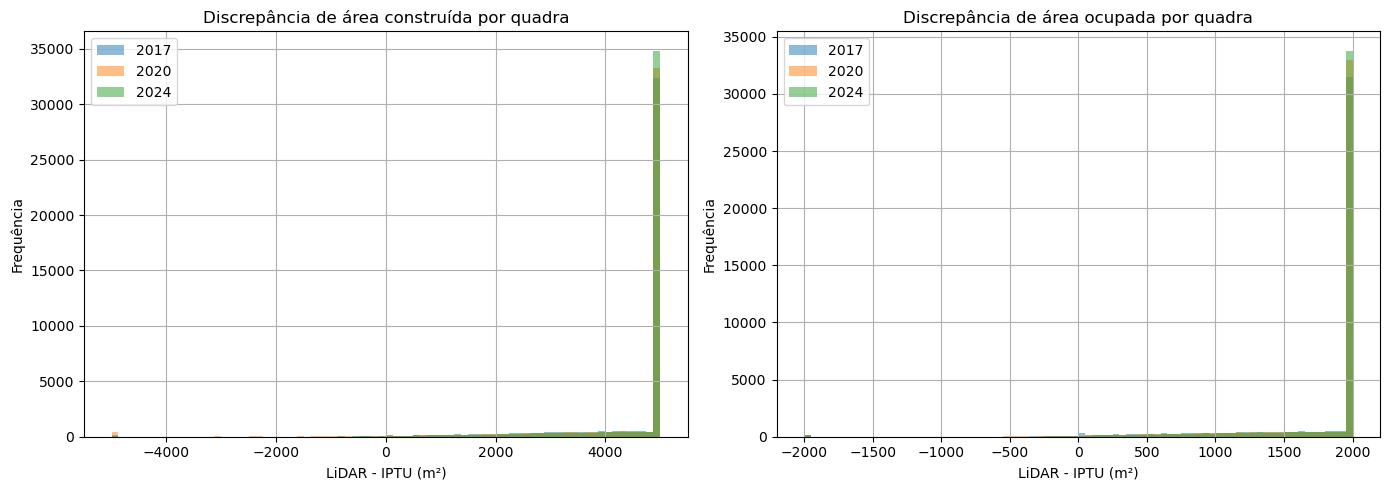

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for year, gdf in gdfs_prepared.items():
    if "diff_area_construida_m2" in gdf.columns:
        gdf["diff_area_construida_m2"].dropna().clip(-5000, 5000).hist(
            bins=80, alpha=0.5, ax=axes[0], label=str(year)
        )
    if "diff_area_ocupada_m2" in gdf.columns:
        gdf["diff_area_ocupada_m2"].dropna().clip(-2000, 2000).hist(
            bins=80, alpha=0.5, ax=axes[1], label=str(year)
        )

axes[0].set_title("Discrepância de área construída por quadra")
axes[0].set_xlabel("LiDAR - IPTU (m²)")
axes[0].set_ylabel("Frequência")
axes[0].legend()

axes[1].set_title("Discrepância de área ocupada por quadra")
axes[1].set_xlabel("LiDAR - IPTU (m²)")
axes[1].set_ylabel("Frequência")
axes[1].legend()

plt.tight_layout()
plt.show()


In [18]:
import numpy as np

for year, gdf in gdfs_prepared.items():
    gdf = gdf.copy()

    # diferença absoluta recalculada
    gdf["diff_area_construida_m2_correct"] = (
        gdf["area_construida_lidar_m2"] - gdf["area_construida_m2"]
    )

    # proporção da área LiDAR não representada no cadastro
    gdf["prop_area_construida_not_in_cadastro"] = np.where(
        gdf["area_construida_lidar_m2"] > 0,
        gdf["diff_area_construida_m2_correct"] / gdf["area_construida_lidar_m2"],
        np.nan
    )

    # em porcentagem
    gdf["pct_area_construida_not_in_cadastro"] = (
        gdf["prop_area_construida_not_in_cadastro"] * 100
    )

    gdfs_prepared[year] = gdf

In [19]:
for year, gdf in gdfs_prepared.items():
    gdf = gdf.copy()

    gdf["pct_area_construida_not_in_cadastro_clipped"] = gdf[
        "pct_area_construida_not_in_cadastro"
    ].clip(-100, 100)

    gdfs_prepared[year] = gdf

In [22]:
import numpy as np

YEAR_TO_MAP = 2024

gdf_map = gdfs_prepared[YEAR_TO_MAP].copy()

col_raw = "pct_area_construida_not_in_cadastro"

# manter só discrepâncias positivas
gdf_map["pct_disc_pos"] = gdf_map[col_raw].where(gdf_map[col_raw] > 0, 0)

# opcional: se preferir mascarar negativos em vez de zerar:
# gdf_map["pct_disc_pos"] = gdf_map[col_raw].where(gdf_map[col_raw] > 0, np.nan)

gdf_map["pct_disc_pos"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

count    47599.000000
mean        55.710365
std         22.799376
min          0.000000
10%         20.852552
25%         47.179095
50%         58.520334
75%         69.503140
90%         81.644824
95%         89.717271
99%        100.000000
max        100.000000
Name: pct_disc_pos, dtype: float64

In [23]:
bins = [0, 10, 20, 30, 50, 70, 100]
labels = ["0–10%", "10–20%", "20–30%", "30–50%", "50–70%", "70–100%"]

gdf_map["disc_class"] = pd.cut(
    gdf_map["pct_disc_pos"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [24]:
gdf_map["pct_disc_pos"] = gdf_map["pct_disc_pos"].clip(0, 100)

In [61]:
from matplotlib.colors import ListedColormap

colors = [
    "#00441b",  # verde ainda mais profundo
    "#2e7d32",
    "#fff59d",
    "#fbc02d",
    "#ef6c00",
    "#7f0000",  # vermelho profundo
]

cmap_manual = ListedColormap(colors)

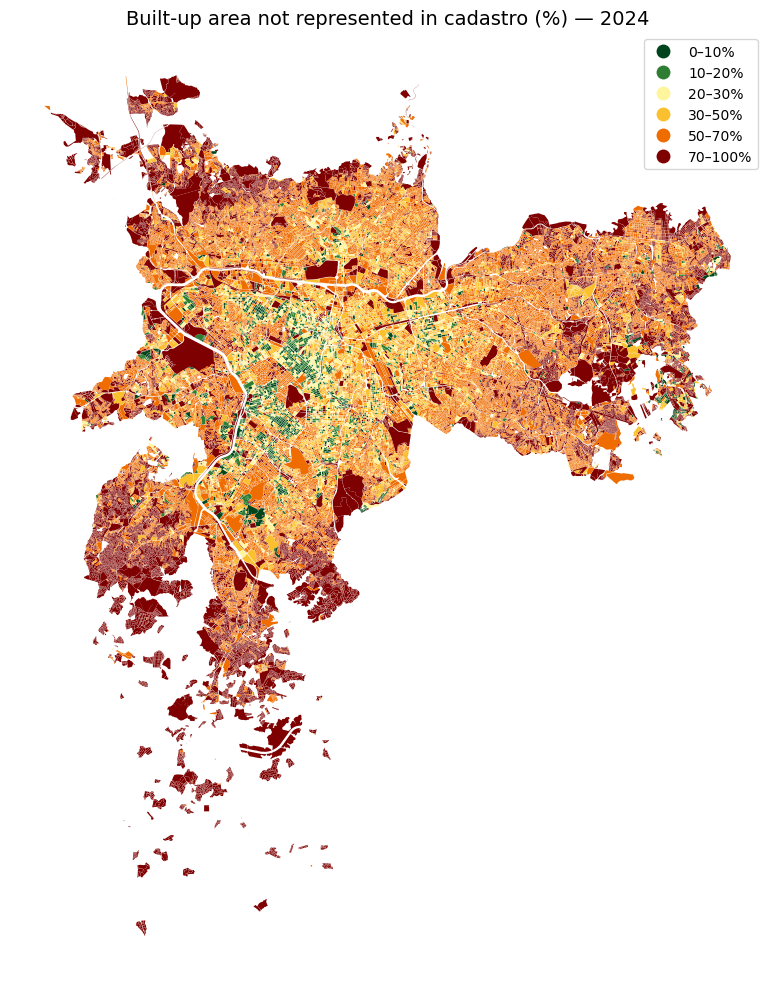

In [62]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

gdf_map.plot(
    column="disc_class",
    categorical=True,
    cmap=cmap_manual,
    linewidth=0,
    legend=True,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

ax.set_title("Built-up area not represented in cadastro (%) — 2024", fontsize=14)
ax.set_axis_off()

plt.tight_layout()
plt.show()

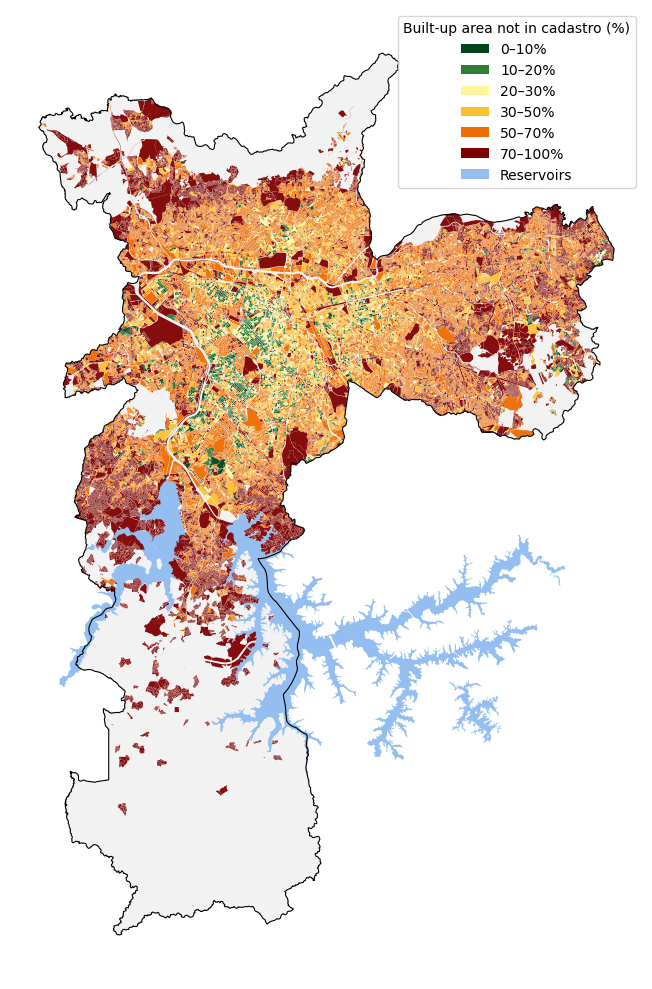

In [63]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- carregar dados base ---
municipio = gpd.read_file("../data/geosampa/municipio.gpkg")
represas = gpd.read_file("../data/geosampa/geoportal_represa_nivel_maximo.gpkg")

# garantir mesmo CRS
municipio = municipio.to_crs(gdf_map.crs)
represas = represas.to_crs(gdf_map.crs)

# --- plot ---
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# 1. fundo do município
municipio.plot(
    ax=ax,
    color="#f2f2f2",
    edgecolor="none"
)

# 2. represas (azul exclusivo)
represas.plot(
    ax=ax,
    color="#94beef",
    edgecolor="none",
    zorder=2
)

# 3. quadras
gdf_map.plot(
    column="disc_class",
    categorical=True,
    cmap=cmap_manual,
    linewidth=0,
    legend=False,  # vamos customizar
    ax=ax,
    alpha=0.95,
    zorder=3
)

# 4. borda do município (IMPORTANTE)
municipio.boundary.plot(
    ax=ax,
    color="black",
    linewidth=0.8,
    zorder=4
)

# --- legenda customizada ---

# legenda das classes
legend_elements = [
    Patch(facecolor=colors[0], label="0–10%"),
    Patch(facecolor=colors[1], label="10–20%"),
    Patch(facecolor=colors[2], label="20–30%"),
    Patch(facecolor=colors[3], label="30–50%"),
    Patch(facecolor=colors[4], label="50–70%"),
    Patch(facecolor=colors[5], label="70–100%"),
    Patch(facecolor="#94beef", label="Reservoirs")
]

ax.legend(
    handles=legend_elements,
    title="Built-up area not in cadastro (%)",
    loc="upper right",
    frameon=True
)

# estética
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [64]:
import numpy as np

for year, gdf in gdfs_prepared.items():
    gdf = gdf.copy()

    # área construída LiDAR
    gdf["area_construida_lidar_m2"] = gdf["sum"] / 3.4

    # CA (coeficiente de aproveitamento)
    gdf["CA_lidar"] = np.where(
        gdf["count_total"] > 0,
        gdf["area_construida_lidar_m2"] / gdf["count_total"],
        np.nan
    )

    # taxa de ocupação
    gdf["TO_lidar"] = np.where(
        gdf["count_total"] > 0,
        gdf["count_valid"] / gdf["count_total"],
        np.nan
    )

    gdfs_prepared[year] = gdf

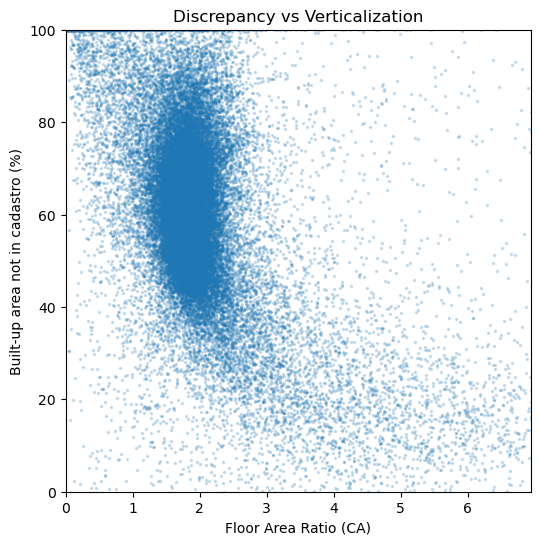

In [72]:
import matplotlib.pyplot as plt
import numpy as np

YEAR = 2024
gdf = gdfs_prepared[YEAR]

x = gdf["CA_lidar"]
y = gdf["pct_area_construida_not_in_cadastro"]

# filtro principal
mask = (
    x.notna() &
    y.notna() &
    (y >= 0) &
    (y <= 100)
)

x_f = x[mask]
y_f = y[mask]

plt.figure(figsize=(6,6))
plt.scatter(x_f, y_f, s=2, alpha=0.2)

plt.xlabel("Floor Area Ratio (CA)")
plt.ylabel("Built-up area not in cadastro (%)")
plt.title("Discrepancy vs Verticalization")

plt.xlim(0, np.percentile(x_f, 99))  # evita cauda longa
plt.ylim(0, 100)

plt.show()

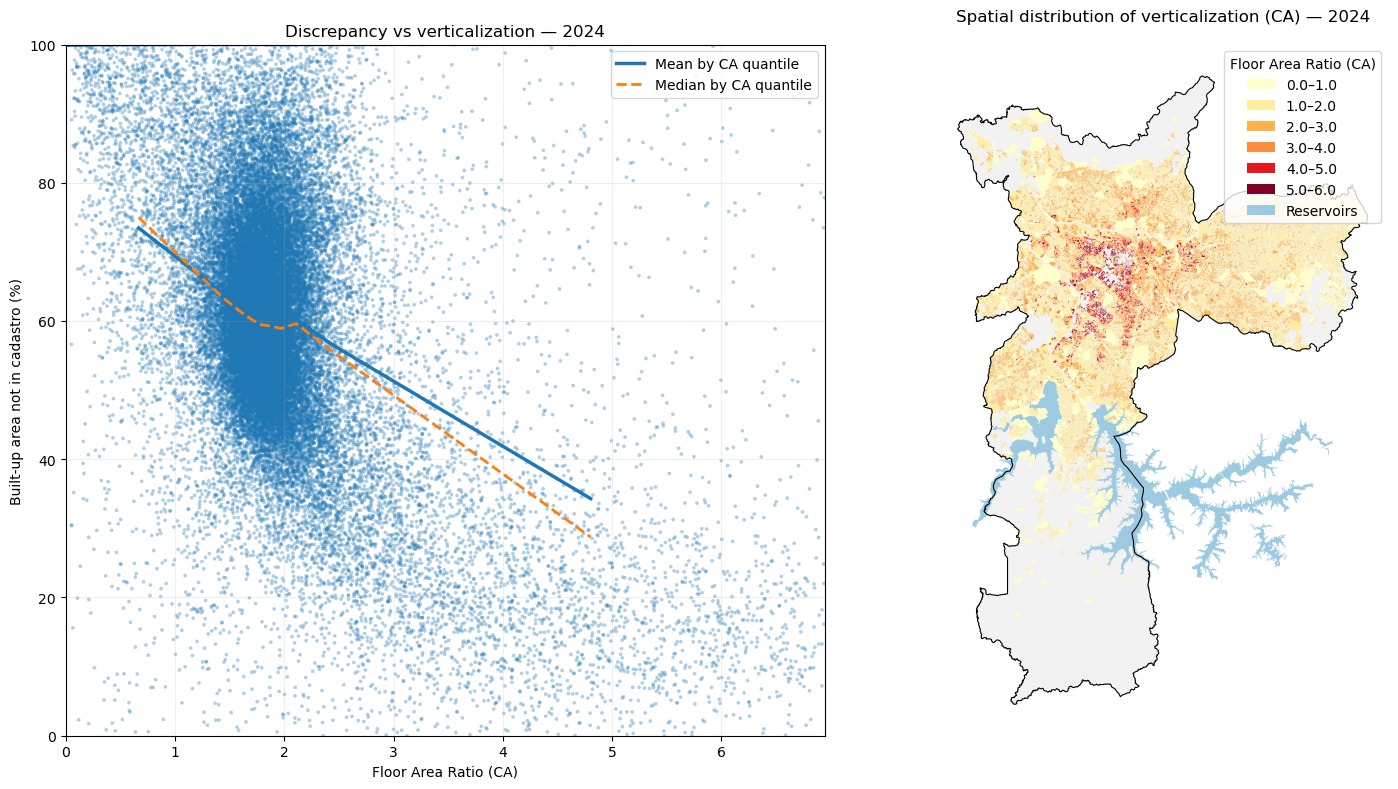

In [89]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

# =========================
# CONFIG
# =========================
YEAR = 2024
HP = 3.4  # altura média por pavimento

# -------------------------
# carregar base do ano
# -------------------------
gdf = gdfs_prepared[YEAR].copy()

# -------------------------
# garantir métricas
# -------------------------
# área construída LiDAR
gdf["area_construida_lidar_m2"] = gdf["sum"] / HP

# CA (coeficiente de aproveitamento / verticalização)
gdf["CA_lidar"] = np.where(
    gdf["count_total"] > 0,
    gdf["area_construida_lidar_m2"] / gdf["count_total"],
    np.nan
)

# discrepância proporcional
gdf["diff_area_construida_m2_correct"] = (
    gdf["area_construida_lidar_m2"] - gdf["area_construida_m2"]
)

gdf["pct_area_construida_not_in_cadastro"] = np.where(
    gdf["area_construida_lidar_m2"] > 0,
    100 * gdf["diff_area_construida_m2_correct"] / gdf["area_construida_lidar_m2"],
    np.nan
)

# =========================
# FILTRO PARA O SCATTER
# =========================
mask_scatter = (
    gdf["CA_lidar"].notna() &
    gdf["pct_area_construida_not_in_cadastro"].notna() &
    (gdf["pct_area_construida_not_in_cadastro"] >= 0) &
    (gdf["pct_area_construida_not_in_cadastro"] <= 100)
)

gdf_scatter = gdf.loc[mask_scatter].copy()

# limitar CA extremo no scatter para melhorar leitura
ca_p99 = gdf_scatter["CA_lidar"].quantile(0.99)
gdf_scatter = gdf_scatter[gdf_scatter["CA_lidar"] <= ca_p99].copy()

# bins por quantil para desenhar tendência robusta
gdf_scatter["CA_bin"] = pd.qcut(gdf_scatter["CA_lidar"], q=10, duplicates="drop")
trend_mean = gdf_scatter.groupby("CA_bin", observed=False)["pct_area_construida_not_in_cadastro"].mean()
trend_median = gdf_scatter.groupby("CA_bin", observed=False)["pct_area_construida_not_in_cadastro"].median()
trend_x = [interval.mid for interval in trend_mean.index]

# =========================
# PREPARO DO MAPA DO CA
# =========================
# carregar base cartográfica
municipio = gpd.read_file("../data/geosampa/municipio.gpkg").to_crs(gdf.crs)
represas = gpd.read_file("../data/geosampa/geoportal_represa_nivel_maximo.gpkg").to_crs(gdf.crs)

# recorte da cauda extrema do CA para mapa
gdf_map = gdf.copy()
ca_map_p99 = gdf_map["CA_lidar"].quantile(0.99)
gdf_map["CA_lidar_clip"] = gdf_map["CA_lidar"].clip(upper=ca_map_p99)

# # classificar CA em 6 classes por quantil
# gdf_map = gdf_map[gdf_map["CA_lidar_clip"].notna()].copy()
# gdf_map["CA_class"] = pd.qcut(gdf_map["CA_lidar_clip"], q=6, duplicates="drop")

# # rótulos mais legíveis para legenda
# ca_intervals = list(gdf_map["CA_class"].cat.categories)
# ca_labels = [f"{iv.left:.2f}–{iv.right:.2f}" for iv in ca_intervals]
# gdf_map["CA_class_label"] = gdf_map["CA_class"].astype(str)
# replace_map = {str(iv): lab for iv, lab in zip(ca_intervals, ca_labels)}
# gdf_map["CA_class_label"] = gdf_map["CA_class_label"].replace(replace_map)

# classes homogêneas de CA (0 a 6)
gdf_map = gdf_map[gdf_map["CA_lidar_clip"].notna()].copy()

ca_bins = np.linspace(0, 6, 7)  # 6 classes iguais
ca_labels = [f"{ca_bins[i]:.1f}–{ca_bins[i+1]:.1f}" for i in range(len(ca_bins)-1)]

gdf_map["CA_class"] = pd.cut(
    gdf_map["CA_lidar_clip"],
    bins=ca_bins,
    labels=ca_labels,
    include_lowest=True
)

gdf_map["CA_class_label"] = gdf_map["CA_class"].astype(str)

# paleta do CA: clara -> escura (sem azul, para não brigar com represa)
ca_colors = [
    "#ffffcc",  # muito claro
    "#ffeda0",
    "#feb24c",
    "#fd8d3c",
    "#e31a1c",
    "#800026",  # bem escuro
]
cmap_ca = ListedColormap(ca_colors)

# =========================
# FIGURA LADO A LADO
# =========================
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16, 8), gridspec_kw={"width_ratios": [1, 1.1]}
)

# ---------------------------------
# PAINEL 1: scatter CA vs discrepância
# ---------------------------------
ax1.scatter(
    gdf_scatter["CA_lidar"],
    gdf_scatter["pct_area_construida_not_in_cadastro"],
    s=7,
    alpha=0.35,
    edgecolors="none"
)

ax1.plot(trend_x, trend_mean.values, linewidth=2.5, label="Mean by CA quantile")
ax1.plot(trend_x, trend_median.values, linewidth=2.0, linestyle="--", label="Median by CA quantile")

ax1.set_xlabel("Floor Area Ratio (CA)")
ax1.set_ylabel("Built-up area not in cadastro (%)")
ax1.set_title(f"Discrepancy vs verticalization — {YEAR}")
ax1.set_ylim(0, 100)
ax1.set_xlim(0, ca_p99)
ax1.legend(frameon=True)
ax1.grid(alpha=0.2)

# ---------------------------------
# PAINEL 2: mapa do CA
# ---------------------------------
municipio.plot(
    ax=ax2,
    color="#f2f2f2",
    edgecolor="none",
    zorder=1
)

represas.plot(
    ax=ax2,
    color="#9ecae1",
    edgecolor="none",
    zorder=2
)

# como o plot categórico com cmap depende da ordem, vamos plotar categoria por categoria
for color, label in zip(ca_colors, ca_labels):
    gdf_map[gdf_map["CA_class_label"] == label].plot(
        ax=ax2,
        color=color,
        linewidth=0,
        zorder=3
    )

municipio.boundary.plot(
    ax=ax2,
    color="black",
    linewidth=0.8,
    zorder=4
)

# legenda manual do mapa
legend_elements = [Patch(facecolor=c, label=l) for c, l in zip(ca_colors, ca_labels)]
legend_elements.append(Patch(facecolor="#9ecae1", label="Reservoirs"))

ax2.legend(
    handles=legend_elements,
    title="Floor Area Ratio (CA)",
    loc="upper right",
    frameon=True
)

ax2.set_title(f"Spatial distribution of verticalization (CA) — {YEAR}")
ax2.set_axis_off()

plt.tight_layout()
plt.show()

In [81]:
print(df.columns)
print(gdf_map.columns)

Index(['year', 'n_quadras', 'sum_area_construida_m2', 'sum_area_construida_lidar_m2', 'sum_diff_area_construida_m2', 'pct_total_area_construida_lidar_vs_iptu', 'sum_area_ocupada_m2',
       'sum_area_ocupada_lidar_m2', 'sum_diff_area_ocupada_m2', 'pct_total_area_ocupada_lidar_vs_iptu', 'mean_pavimentos_min', 'mean_pavimentos_lidar_min', 'mean_pavimentos_max',
       'mean_pavimentos_lidar_max', 'sum_area_construida_km2', 'sum_area_construida_lidar_km2', 'sum_diff_area_construida_km2', 'sum_area_ocupada_km2', 'sum_area_ocupada_lidar_km2',
       'sum_diff_area_ocupada_km2'],
      dtype='object')
Index(['qd_fiscal_cad', 'qd_id_cad', 'qd_setor_cad', 'SQ', 'setor', 'quadra', 'area_terreno_m2', 'area_construida_m2', 'area_ocupada_m2', 'pavimentos_min', 'pavimentos_max', 'ano', 'year',
       'qd_id_lidar', 'qd_setor_lidar', 'qd_fiscal_lidar', 'area_m2', 'count_total', 'min', 'max', 'mean', 'count_valid', 'sum', 'std', 'median', 'valid_frac', 'nodata_frac', 'valid_area_m2',
       'raster',